The problem with z-score data is that it is only for normal data if you know the distribution is not normal or skewed youd shouldn't use tha for this we can use the IQR method.

# The Deep Intuition: The Boxplot Math
When your data is skewed, you drop the Z-score and switch to the Interquartile Range (IQR) Method.
Instead of looking at the Average, the IQR method only cares about the Middle 50% of your data.

1. Q1 (25th Percentile): The value where 25% of the data is below it.

2. Q3 (75th Percentile): The value where 75% of the data is below it.

3. The IQR: The distance between Q3 and Q1 (the "Box" in a boxplot).

4. The Whiskers (Boundaries): To find outliers, you take the IQR, multiply it by 1.5, and stretch it outward from the box. Anything past those whiskers is an outlier.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 9.444444444444438, 'See right skewed data(Salary)')

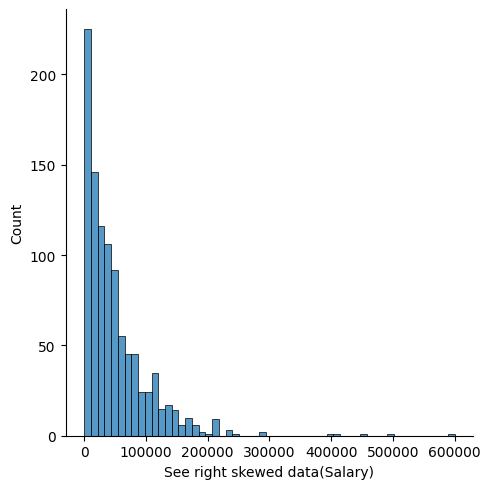

In [9]:
# let's create a skewed data like salaries
np.random.seed(42)
# Generate 1000 skewed salaries (most people make around $40k-$60k)
skewed_salaries = np.random.exponential(scale=50000, size=1000)

# Inject some extreme billionaire outliers
billionaires = np.array([400000, 450000, 500000, 600000])
data = np.concatenate([skewed_salaries, billionaires])

df = pd.DataFrame({'Salary': data})

sns.displot(df['Salary'])
plt.xlabel("See right skewed data(Salary)")

In [10]:
# IQR Boundaries
q1 = df['Salary'].quantile(0.25)
q3 = df['Salary'].quantile(0.75)
iqr = q3 -q1

print(f"Q1 (25th Percentile): ${q1:,.0f}")
print(f"Q3 (75th Percentile): ${q3:,.0f}")
print(f"The IQR (Middle 50%): ${iqr:,.0f}")

Q1 (25th Percentile): $13,541
Q3 (75th Percentile): $68,666
The IQR (Middle 50%): $55,125


In [12]:
# let's calculate the exact boundaries
upper_limit = q3 + (1.5 * iqr)
lower_limit = q1 - (1.5 * iqr)

# count outliers
outliers = df[(df['Salary'] > upper_limit) | (df['Salary'] < lower_limit)]
outliers.shape

(45, 1)

<Axes: ylabel='Salary'>

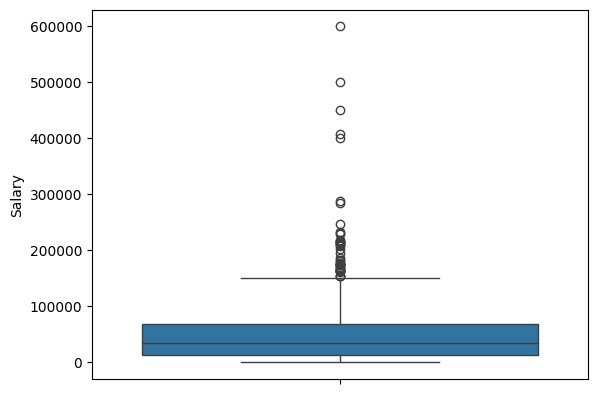

In [13]:
# let's visualize initial boxplot of the original data
sns.boxplot(df['Salary'])

<Axes: ylabel='Salary'>

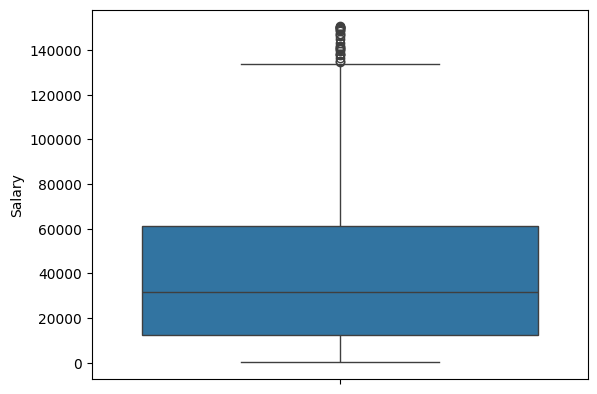

In [16]:
# Trimming and visualize
df_trimmed = df[(df['Salary'] <= upper_limit) & (df['Salary'] >= lower_limit)]

sns.boxplot(df_trimmed['Salary'])

<Axes: ylabel='Salary'>

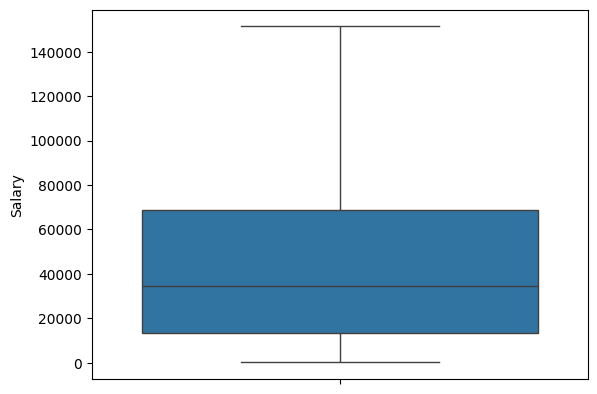

In [17]:
# capping and visualize
df_capping = df.copy()

df_capping['Salary'] = np.where(
    df_capping['Salary'] > upper_limit, upper_limit,
    np.where(df_capping['Salary'] < lower_limit, lower_limit, df_capping['Salary'])
)

sns.boxplot(df_capping['Salary'])

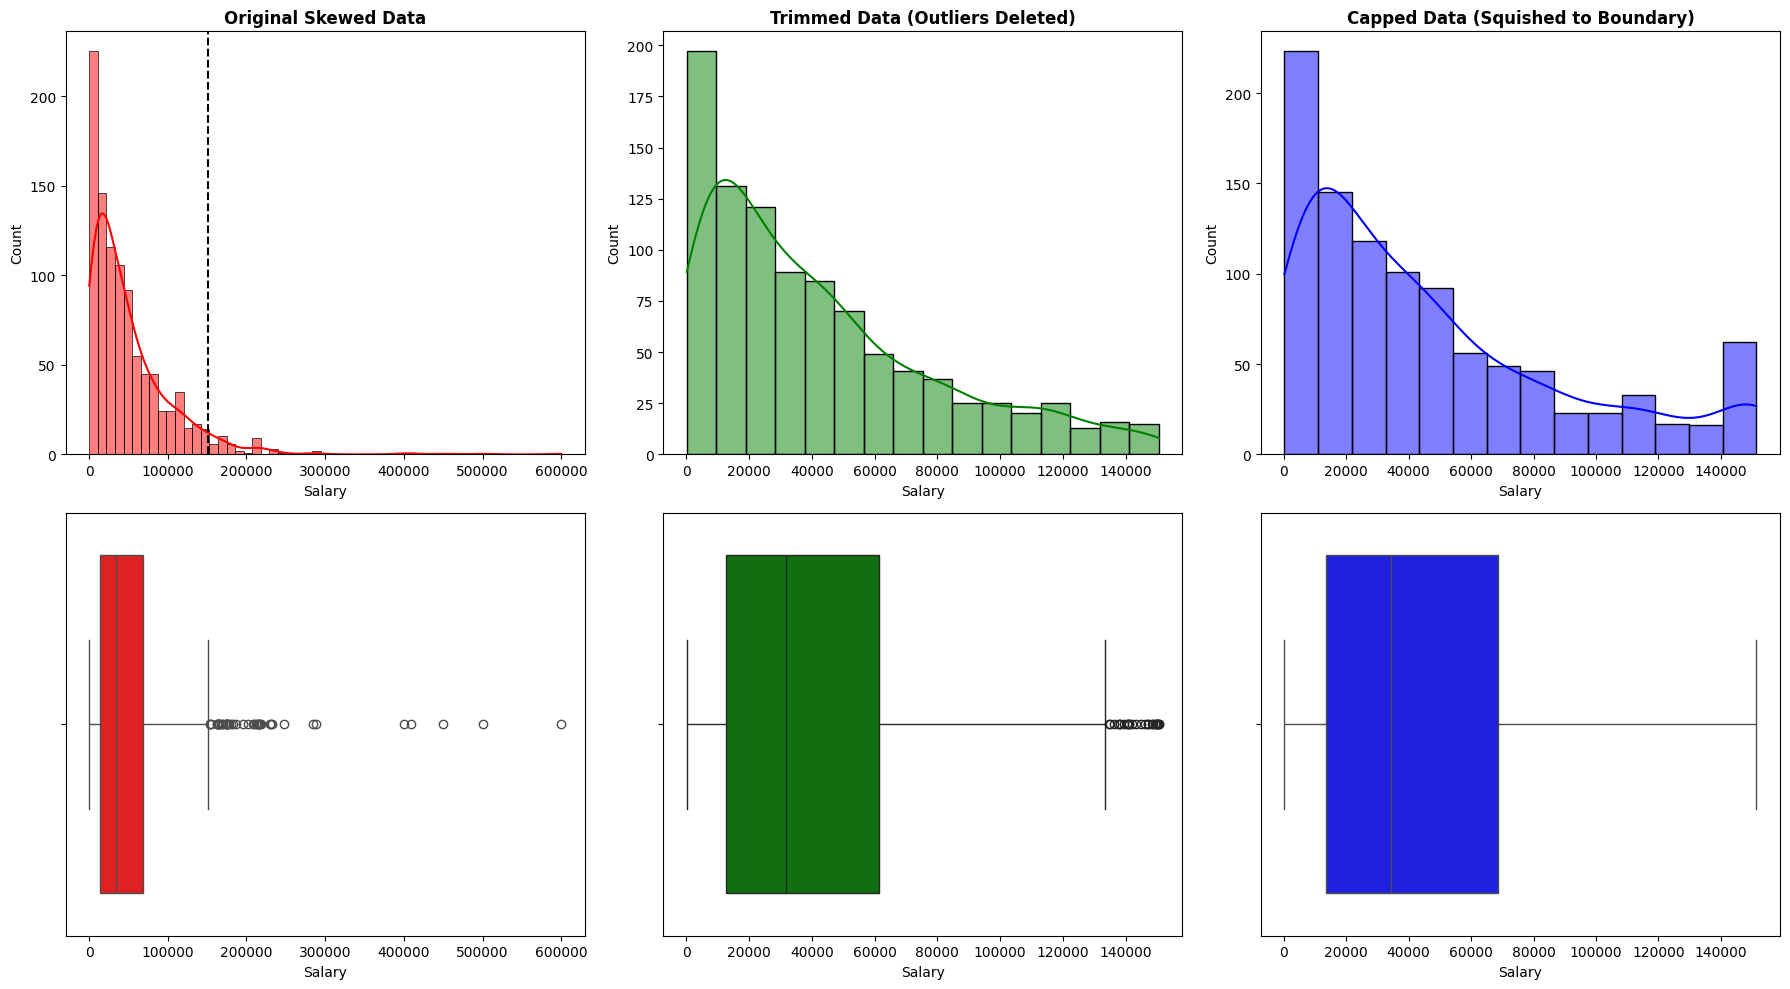

In [19]:
# complete comparison visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Row 1: Distribution (KDE) Plots
sns.histplot(df['Salary'], kde=True, ax=axes[0, 0], color='red')
axes[0, 0].set_title('Original Skewed Data', fontweight='bold')
axes[0, 0].axvline(upper_limit, color='black', linestyle='--')

sns.histplot(df_trimmed['Salary'], kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('Trimmed Data (Outliers Deleted)', fontweight='bold')

sns.histplot(df_capping['Salary'], kde=True, ax=axes[0, 2], color='blue')
axes[0, 2].set_title('Capped Data (Squished to Boundary)', fontweight='bold')

# Row 2: Boxplots
sns.boxplot(x=df['Salary'], ax=axes[1, 0], color='red')
sns.boxplot(x=df_trimmed['Salary'], ax=axes[1, 1], color='green')
sns.boxplot(x=df_capping['Salary'], ax=axes[1, 2], color='blue')

plt.tight_layout()
plt.show()

What you should notice:
When the plots generate, look at the first red distribution curve. It does not look like a bell curve at all; it starts high on the left and drops off quickly.
Because the IQR method only uses percentiles (where the data ranks in a lineup), it wasn't fooled by that massive right-pointing tail. It successfully drew a boundary and caught the extreme outliers without deleting half your dataset.